In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Добавим некоторые данные из pretrain набора

In [2]:
pretrain = pl.read_parquet("../data/pretrain_part_1.parquet")

In [3]:
pretrain = pretrain.with_columns(pl.col("event_dttm").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S")\
                                 .alias("event_dttm")).with_columns(pl.col("event_dttm").dt.hour().alias("Hour"))

# pretrain = pretrain.with_columns(pl.col("event_dttm").str.strptime(pl.Time, format="%H").alias("Hour"))

In [4]:
pre_agg = pretrain.group_by("customer_id").agg([
    pl.col("operaton_amt").mean().alias("mean_amt_pre"),
    pl.col("operaton_amt").median().alias("median_amt_pre"),
    pl.col("operaton_amt").std().alias("std_amt_pre"),
    pl.col("event_id").count().alias("ops_pre"),
    pl.col("Hour").mode().alias("most_common_hour_pre")])

pre_agg = pre_agg.with_columns(pl.col("most_common_hour_pre").list.first().alias("most_common_hour_pre"))
del pretrain
gc.collect()

0

In [5]:
pre_agg

customer_id,mean_amt_pre,median_amt_pre,std_amt_pre,ops_pre,most_common_hour_pre
i64,f64,f64,f64,u32,i8
123440950707831,2.3430e6,1.640292e6,3.4364e6,283,7
123157482861591,839489.215321,108202.5,3.1867e6,1200,8
123269152015120,4.9617e6,2336826.5,6.2264e6,594,15
123329281554323,246606.843794,30249.0,1.5388e6,1244,13
123226202338807,76179.995789,22855.0,154217.958402,760,14
…,…,…,…,…,…
123337871492166,1.2091e6,99240.0,6.1511e6,1799,18
123312101688363,198191.564928,59471.0,658586.742766,1116,9
123303511752702,5.4458e6,300330.0,2.8032e7,731,4


Загрузим полный набор данных

In [6]:
train_part1 = pl.scan_parquet("../ClearData_for_part_4/train_full.parquet")
# train_part1.shape

In [7]:
train_part1.schema

/tmp/ipykernel_3206/896344679.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  train_part1.schema


Schema([('customer_id', Int64),
        ('event_dttm', String),
        ('event_type_nm', Int16),
        ('event_desc', Int16),
        ('channel_indicator_type', Int16),
        ('channel_indicator_sub_type', Int16),
        ('operaton_amt', Float64),
        ('currency_iso_cd', Int16),
        ('mcc_code', Int16),
        ('pos_cd', Int16),
        ('timezone', Int16),
        ('session_id', Float64),
        ('operating_system_type', Int16),
        ('battery', String),
        ('device_system_version', String),
        ('screen_size', String),
        ('developer_tools', Int16),
        ('phone_voip_call_state', Int16),
        ('web_rdp_connection', Int16),
        ('compromised', Int16),
        ('Hour', Int16),
        ('target', Int16)])

In [8]:
pos_class = train_part1.filter(pl.col("target") == 1).collect()
pos_class.shape

(51438, 22)

In [9]:
train_part1 = train_part1.filter(pl.col("target") != 1).collect()
train_part1.shape

(85626402, 22)

In [10]:
neg_class = 13_000_000
train_part1 = train_part1.sample(n=neg_class)

# columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
#            "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

# for i in columns:
#     train_part1 = train_part1.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

In [11]:
train_part1 = pl.concat([train_part1, pos_class])
train_part1 = train_part1.sample(fraction=1.0, shuffle=True)
train_part1.shape

(13051438, 22)

In [12]:
train_part1 = train_part1.sort("event_dttm")
train_part1 = train_part1.drop("event_dttm")

In [13]:
x = train_part1.drop("target")
y = train_part1["target"]

In [14]:
# X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle=False)   
X_train = x[:int(0.9*len(x))]
X_test = x[int(0.9*len(x)):]
y_train = y[:int(0.9*len(y))]
y_test = y[int(0.9*len(y)):]

In [15]:
# cat_features = ["event_type_nm", "event_desc", "channel_indicator_type", "channel_indicator_sub_type", \
#                 "currency_iso_cd", "mcc_code", "pos_cd", "timezone", "operating_system_type", "battery",\
#                 "device_system_version", "screen_size", \
#                 "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised"]

# cat_features = [
#     'mcc_code', 'event_desc', 'channel_indicator_type',
#     'timezone', 'operating_system_type', 'device_system_version',
#     'screen_size', 'battery'
# ]

columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
           "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

for i in columns:
    X_train = X_train.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

for i in columns:
    X_test = X_test.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery'
]

for i in cat_features:
    X_train = X_train.with_columns(pl.col(i).fill_null('missing'))

for i in cat_features:
    X_test = X_test.with_columns(pl.col(i).fill_null('missing'))

In [16]:
X_train = X_train.with_columns(pl.concat_str([pl.col("operating_system_type"), pl.col("device_system_version"), 
    pl.col("screen_size"), pl.col("battery")], separator="_").alias("device_info"))

X_test = X_test.with_columns(pl.concat_str([pl.col("operating_system_type"), pl.col("device_system_version"), 
    pl.col("screen_size"), pl.col("battery")], separator="_").alias("device_info"))

In [17]:
X_train = X_train.join(pre_agg, on="customer_id", how="left")
X_test = X_test.join(pre_agg, on="customer_id", how="left")

X_train = X_train.drop("customer_id")
X_test = X_test.drop("customer_id")

# # Новые фичи
# X_train = X_train.with_columns([
#     (pl.col("operaton_amt") / pl.col("mean_amt_pre")).alias("amount_ratio_pre"),
#     ((pl.col("operaton_amt") - pl.col("mean_amt_pre")) / (pl.col("std_amt_pre") + 1)).alias("amt_zscore_pre")])

# X_test = X_test.with_columns([
#     (pl.col("operaton_amt") / pl.col("mean_amt_pre")).alias("amount_ratio_pre"),
#     ((pl.col("operaton_amt") - pl.col("mean_amt_pre")) / (pl.col("std_amt_pre") + 1)).alias("amt_zscore_pre")])

In [18]:
X_train

event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,timezone,session_id,operating_system_type,battery,device_system_version,screen_size,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,Hour,device_info,mean_amt_pre,median_amt_pre,std_amt_pre,ops_pre,most_common_hour_pre
i16,str,i16,i16,f64,i16,str,i16,str,f64,str,str,str,str,i16,i16,i16,i16,i16,str,f64,f64,f64,u32,i8
14,"""75""",6,2,64978.0,0,"""3""",1,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null
7,"""56""",4,15,null,null,"""missing""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null
14,"""75""",6,5,39693.0,0,"""13""",1,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",310500.778496,50065.0,2.7319e6,1537,5
14,"""75""",6,5,35853.0,0,"""19""",3,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null
14,"""101""",4,15,3005.0,0,"""missing""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
14,"""75""",0,5,103979.0,0,"""1""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,2,"""missing_missing_missing_missin…",null,null,null,null,null
7,"""56""",4,15,null,null,"""missing""",null,"""missing""",1.2341e14,"""missing""","""missing""","""14""","""720x1488""",0,0,null,0,2,"""missing_14_720x1488_missing""",null,null,null,null,null
7,"""56""",4,15,null,null,"""missing""",null,"""missing""",1.2323e14,"""missing""","""missing""","""13""","""1080x2167""",1,0,null,0,2,"""missing_13_1080x2167_missing""",1.3545e6,499300.0,3.0047e6,1166,12


In [19]:
del train_part1, x, y
gc.collect()

0

In [20]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [21]:
cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery', 'device_info']

In [22]:
# CatBoost = CatBoostClassifier(iterations=50, depth=5, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

In [23]:
# train_models(CatBoost, X_train, X_test, y_train, y_test)

Попробуем настроить веса меток самостоятельно

In [24]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9444881083344244
Precision: 0.027802037391689488
Recall: 0.38336809961076107
F1-score: 0.05184430132918819
PR-AUC: 0.04490855585285038

Test metrics:
Accuracy: 0.9544693918831945
Precision: 0.029448848817728034
Recall: 0.3453514279927081
F1-score: 0.05426998122035841
PR-AUC: 0.0461257893292896

Confusion matrix


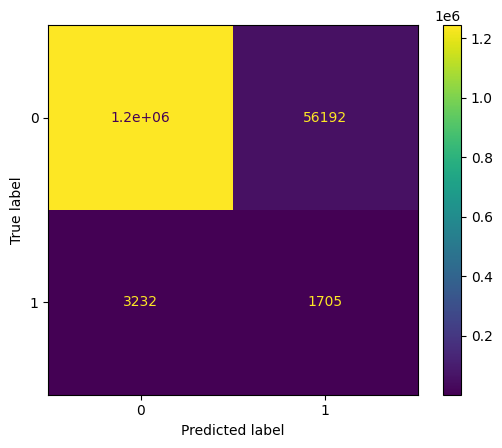

In [25]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [26]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=6, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9421311947410818
Precision: 0.027738624210775956
Recall: 0.39992688329283244
F1-score: 0.05187896303446044
PR-AUC: 0.04694496035324937

Test metrics:
Accuracy: 0.9526833820635884
Precision: 0.02870035502173264
Recall: 0.35041523192221996
F1-score: 0.053055278693552095
PR-AUC: 0.04593476900723999

Confusion matrix


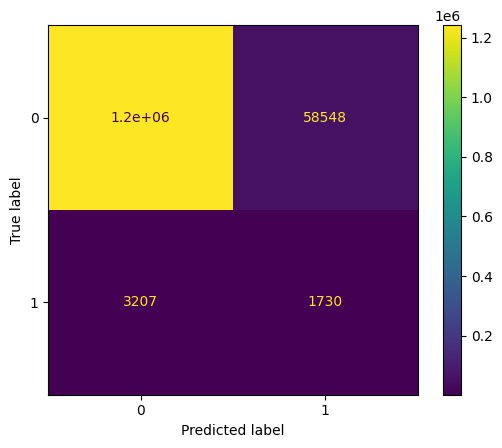

In [27]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [28]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,operaton_amt,19.234172
1,mcc_code,11.175333
2,pos_cd,8.314505
3,event_type_nm,7.166899
4,Hour,6.120178
5,median_amt_pre,5.399991
6,channel_indicator_type,5.242606
7,event_desc,4.532429
8,ops_pre,4.414691
9,channel_indicator_sub_type,3.973552


In [29]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9408282305891543
Precision: 0.02783699096076787
Recall: 0.4111309434205716
F1-score: 0.05214343672651152
PR-AUC: 0.04894451045749304

Test metrics:
Accuracy: 0.9514950074474541
Precision: 0.0290011781224279
Recall: 0.36398622645331175
F1-score: 0.05372197309417041
PR-AUC: 0.044846288035814544

Confusion matrix


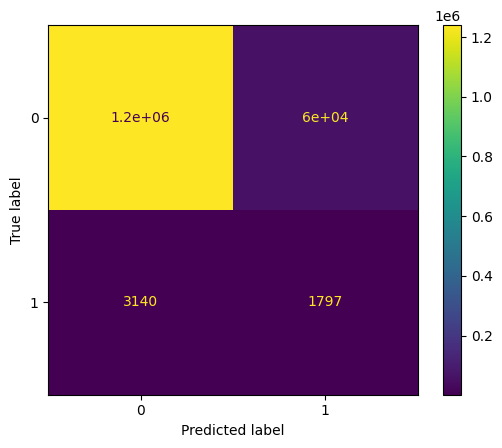

In [30]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [31]:
cat_features = [
    'mcc_code', 'event_desc', 'channel_indicator_type',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery', 'device_info']

In [32]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9441387215405983
Precision: 0.029096352412672322
Recall: 0.40504505279456354
F1-score: 0.05429260355157509
PR-AUC: 0.048960990982239695

Test metrics:
Accuracy: 0.9544172903526355
Precision: 0.029170622249072235
Recall: 0.34231314563500104
F1-score: 0.053760020358824274
PR-AUC: 0.04527923614371538

Confusion matrix


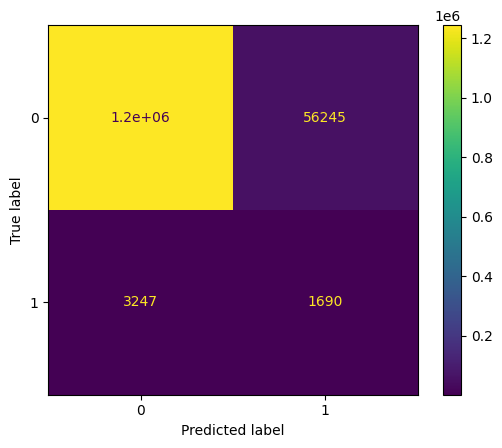

In [33]:
train_models(CatBoost, X_train, X_test, y_train, y_test)